# Paso E: Analisis de vecindarios y sintesis final

1. **Vecindarios de fonemas compartidos** — para cada fonema en comun, sus vecinos en ES son analogos a sus vecinos en FR?
2. **Vecindarios de fonestemas compartidos** — las silabas compartidas mas frecuentes, que vecinos tienen en cada idioma?
3. **Neighborhood overlap** — metrica cuantitativa de solapamiento de vecindarios
4. **UMAP comparativo** — visualizacion final de los tres niveles lado a lado
5. **Tabla de sintesis** — todos los hallazgos en una tabla

In [2]:
import sys
sys.path.insert(0, ".")

from loader import (load_all_models, get_vocab, load_frequency,
                    PHONEME_INVENTORY, PHONEME_FEATURES)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import json

models = load_all_models()

shared_tokens = {}
for level in ("phoneme", "syllable", "word"):
    with open(f"shared_{level}_tokens.json") as f:
        shared_tokens[level] = json.load(f)

print("Loaded.")

Loaded.


## 1. Vecindarios de fonemas compartidos

Para cada fonema compartido, mostramos sus 5 vecinos mas cercanos en ES y en FR. Los vecinos se restringen al inventario de cada idioma.

In [3]:
def get_neighbors(model, token, lang, topn=5):
    """Get nearest neighbors restricted to language inventory."""
    inventory = sorted(PHONEME_INVENTORY[lang])
    # Build similarity against inventory only
    token_vec = model.wv[token].reshape(1, -1)
    inv_vecs = np.array([model.wv[t] for t in inventory])
    sims = cosine_similarity(token_vec, inv_vecs)[0]
    
    # Exclude the token itself
    ranked = []
    for idx in np.argsort(-sims):
        if inventory[idx] != token:
            ranked.append((inventory[idx], sims[idx]))
        if len(ranked) == topn:
            break
    return ranked


rows = []
for ph in shared_tokens["phoneme"]:
    es_neighbors = get_neighbors(models["phoneme"]["es"], ph, "es", topn=5)
    fr_neighbors = get_neighbors(models["phoneme"]["fr"], ph, "fr", topn=5)
    
    es_nn_tokens = [t for t, _ in es_neighbors]
    fr_nn_tokens = [t for t, _ in fr_neighbors]
    overlap = set(es_nn_tokens) & set(fr_nn_tokens)
    
    feats = PHONEME_FEATURES.get(ph, {})
    ph_type = feats.get("type", "?")
    
    rows.append({
        "Phoneme": ph,
        "Type": ph_type,
        "ES neighbors": " ".join([f"{t}({s:.2f})" for t, s in es_neighbors]),
        "FR neighbors": " ".join([f"{t}({s:.2f})" for t, s in fr_neighbors]),
        "Overlap": len(overlap),
        "Shared neighbors": ", ".join(sorted(overlap)) if overlap else "—",
    })

nn_df = pd.DataFrame(rows)
print(f"Mean neighbor overlap (out of 5): {nn_df['Overlap'].mean():.2f}")
print(f"Phonemes with >=2 shared neighbors: {(nn_df['Overlap'] >= 2).sum()} / {len(nn_df)}")
print()
nn_df

Mean neighbor overlap (out of 5): 1.80
Phonemes with >=2 shared neighbors: 14 / 20



,Phoneme,Type,ES neighbors,FR neighbors,Overlap,Shared neighbors
0,a,vowel,e(0.91) o(0.89) i(0.81) d(0.80) l(0.80),ɛ(0.91) y(0.88) i(0.87) ɔ(0.85) d(0.84),2,"d, i"
1,b,consonant,d(0.76) m(0.74) ɾ(0.74) t(0.74) n(0.74),d(0.78) v(0.78) m(0.77) ʒ(0.76) k(0.76),2,"d, m"
2,d,consonant,s(0.86) l(0.85) n(0.84) ɾ(0.81) p(0.81),l(0.95) t(0.94) p(0.92) ɛ(0.91) k(0.91),2,"l, p"
3,e,vowel,a(0.91) o(0.89) i(0.84) s(0.81) u(0.81),ɛ(0.90) y(0.90) i(0.87) p(0.87) d(0.87),1,i
4,f,consonant,k(0.67) t(0.66) s(0.66) n(0.65) i(0.63),d(0.84) m(0.84) t(0.84) p(0.83) k(0.83),2,"k, t"
5,i,vowel,u(0.89) o(0.85) e(0.84) a(0.81) s(0.81),ɛ(0.91) ɑ̃(0.88) l(0.87) e(0.87) a(0.87),2,"a, e"
6,j,consonant,l(0.80) e(0.79) o(0.78) d(0.77) u(0.76),d(0.84) k(0.84) p(0.81) e(0.81) s(0.80),2,"d, e"
7,k,consonant,s(0.87) t(0.84) m(0.84) n(0.82) p(0.78),s(0.92) t(0.91) d(0.91) p(0.88) l(0.88),3,"p, s, t"
8,l,consonant,s(0.86) ɾ(0.86) d(0.85) n(0.85) t(0.85),d(0.95) t(0.92) ɛ(0.91) s(0.90) p(0.89),3,"d, s, t"
9,m,consonant,s(0.89) ɾ(0.86) t(0.85) n(0.85) k(0.84),n(0.90) d(0.88) l(0.87) k(0.87) t(0.86),3,"k, n, t"


## 2. Neighborhood overlap cuantitativo por nivel

Para cada token compartido, calculamos cuantos de sus k vecinos mas cercanos son los mismos en ambos idiomas. Para fonemas los vecinos se restringen al inventario; para silabas y palabras a los tokens compartidos.

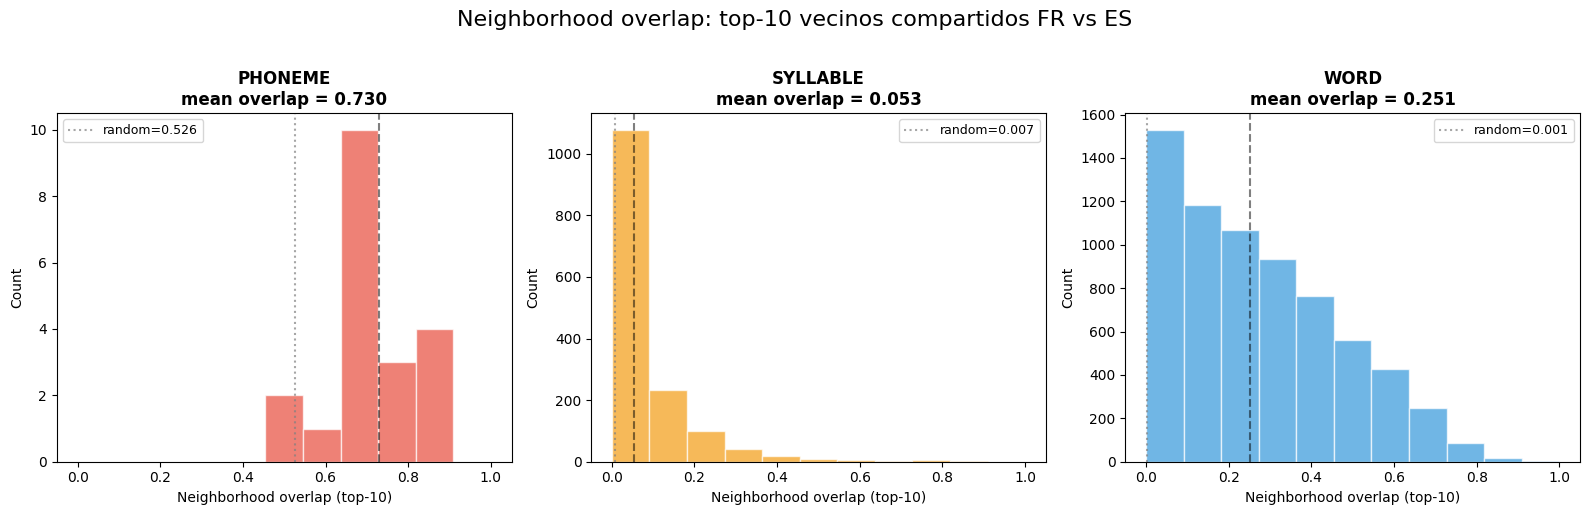

,Nivel,N tokens,Top-k,Mean overlap,Random baseline,Lift
0,phoneme,20,10,0.7300,0.5263,1.3870
1,syllable,1497,10,0.0532,0.0067,7.9647
2,word,6827,10,0.2513,0.0015,171.5149


In [4]:
def compute_neighborhood_overlap(model_es, model_fr, tokens, topn=10):
    """For each shared token, compute overlap of top-n neighbors across languages.
    Neighbors are restricted to the shared token set."""
    es_vecs = np.array([model_es.wv[t] for t in tokens])
    fr_vecs = np.array([model_fr.wv[t] for t in tokens])
    
    sim_es = cosine_similarity(es_vecs)
    sim_fr = cosine_similarity(fr_vecs)
    
    overlaps = []
    for i in range(len(tokens)):
        # Top-n neighbors (excluding self)
        es_nn = set(np.argsort(-sim_es[i])[1:topn+1])
        fr_nn = set(np.argsort(-sim_fr[i])[1:topn+1])
        overlap = len(es_nn & fr_nn)
        overlaps.append(overlap / topn)  # normalize to [0,1]
    
    return np.array(overlaps)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
topn = 10

overlap_results = []
for idx, level in enumerate(("phoneme", "syllable", "word")):
    ax = axes[idx]
    tokens = shared_tokens[level]
    
    overlaps = compute_neighborhood_overlap(
        models[level]["es"], models[level]["fr"], tokens, topn=topn)
    
    ax.hist(overlaps, bins=topn+1, range=(0, 1), alpha=0.7, color=["#e74c3c", "#f39c12", "#3498db"][idx],
           edgecolor="white")
    ax.set_xlabel(f"Neighborhood overlap (top-{topn})")
    ax.set_ylabel("Count")
    mean_ov = overlaps.mean()
    ax.set_title(f"{level.upper()}\nmean overlap = {mean_ov:.3f}", fontsize=12, fontweight="bold")
    ax.axvline(x=mean_ov, color="black", linestyle="--", alpha=0.5)
    
    # Random baseline: expected overlap for random sets of size topn from N items
    n = len(tokens)
    random_baseline = topn / (n - 1) if n > 1 else 0
    ax.axvline(x=random_baseline, color="gray", linestyle=":", alpha=0.7, label=f"random={random_baseline:.3f}")
    ax.legend(fontsize=9)
    
    overlap_results.append({
        "Nivel": level,
        "N tokens": n,
        "Top-k": topn,
        "Mean overlap": mean_ov,
        "Random baseline": random_baseline,
        "Lift": mean_ov / random_baseline if random_baseline > 0 else np.inf,
    })

plt.suptitle(f"Neighborhood overlap: top-{topn} vecinos compartidos FR vs ES", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("neighborhood_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(overlap_results).round(4)

## 3. Vecindarios de fonestemas (silabas) — inspeccion cualitativa

Para las 20 silabas compartidas mas frecuentes, mostramos sus vecinos mas cercanos en cada idioma (restringidos a silabas compartidas). Buscamos patrones fonestemicos: silabas con estructura fonetica similar se agrupan?

In [5]:
# Top shared syllables by combined frequency
freq_es = load_frequency("syllable", "es").set_index("token")["freq"]
freq_fr = load_frequency("syllable", "fr").set_index("token")["freq"]

syl_tokens = shared_tokens["syllable"]
syl_freq = [(t, freq_es.get(t, 0) + freq_fr.get(t, 0)) for t in syl_tokens]
top_syls = sorted(syl_freq, key=lambda x: x[1], reverse=True)[:20]

# Get vectors for all shared syllables
es_vecs = np.array([models["syllable"]["es"].wv[t] for t in syl_tokens])
fr_vecs = np.array([models["syllable"]["fr"].wv[t] for t in syl_tokens])

sim_es = cosine_similarity(es_vecs)
sim_fr = cosine_similarity(fr_vecs)

topn = 5
rows = []
for syl, freq in top_syls:
    i = syl_tokens.index(syl)
    
    es_nn_idx = np.argsort(-sim_es[i])[1:topn+1]
    fr_nn_idx = np.argsort(-sim_fr[i])[1:topn+1]
    
    es_nn = [syl_tokens[j] for j in es_nn_idx]
    fr_nn = [syl_tokens[j] for j in fr_nn_idx]
    overlap = set(es_nn) & set(fr_nn)
    
    rows.append({
        "Syllable": syl,
        "Freq (ES+FR)": freq,
        "ES neighbors": ", ".join(es_nn),
        "FR neighbors": ", ".join(fr_nn),
        "Overlap": len(overlap),
        "Shared": ", ".join(sorted(overlap)) if overlap else "—",
    })

syl_nn_df = pd.DataFrame(rows)
syl_nn_df

,Syllable,Freq (ES+FR),ES neighbors,FR neighbors,Overlap,Shared
0,de,1645463,"la, i, del, kon, a","la, koin, a, ki, su",2,"a, la"
1,la,1386694,"de, da, ka, su, dad","a, tut, l, ot, te",0,—
2,te,761682,"tes, su, do, del, la","la, ɛ, l, tut, fje",1,la
3,a,738859,"ke, kon, de, su, se","la, o, k, l, d",0,—
4,si,644142,"i, se, de, ko, mo","pal, ak, sik, sip, ɛ",0,—
5,ta,642049,"tas, tan, to, i, de","te, mawa, sa, tal, ɛ",0,—
6,se,640739,"ke, de, a, la, kon","sa, li, te, ete, le",0,—
7,ka,564693,"ko, la, kas, de, i","ko, ke, na, si, ɛ",1,ko
8,to,531345,"ta, de, kon, ko, del","mo, iko, teo, is, ɛ",0,—
9,ti,511473,"mo, ka, fi, kon, la","pli, tik, tis, mo, ɛ",1,mo


## 4. UMAP comparativo: tres niveles lado a lado

Visualizacion final de los tokens compartidos en cada nivel, coloreados por cluster, con UMAP para mejor preservacion de estructura global que t-SNE.

/home/estebanpc/miniconda3/envs/phonemst/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/estebanpc/miniconda3/envs/phonemst/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/estebanpc/miniconda3/envs/phonemst/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/estebanpc/miniconda3/envs/phonemst/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/estebanpc/miniconda3/envs/phonemst/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by 

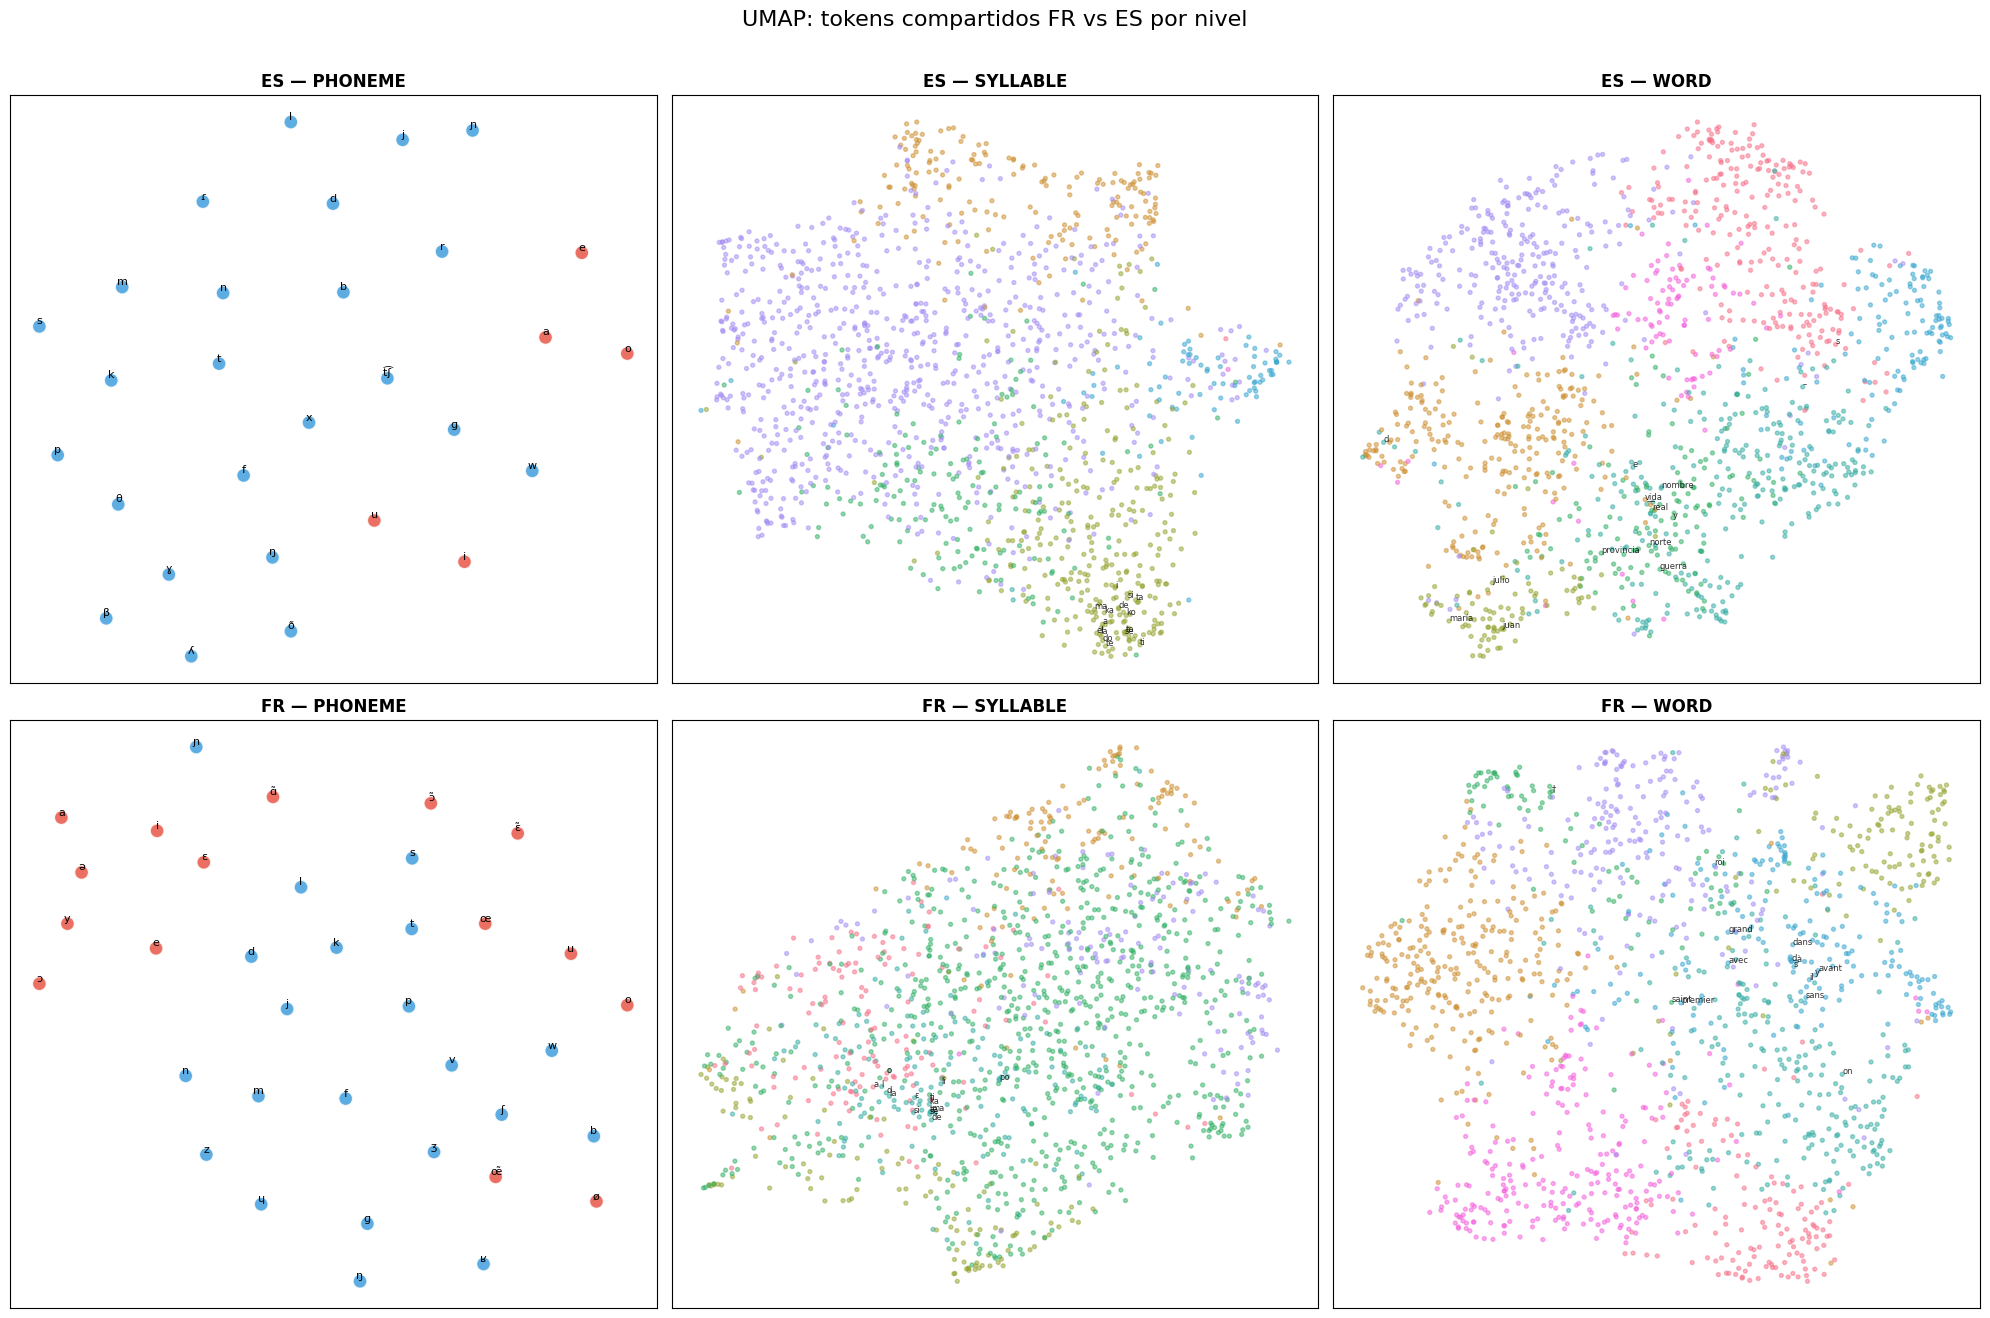

In [6]:
import umap
from sklearn.cluster import KMeans

fig, axes = plt.subplots(2, 3, figsize=(20, 13))

for col, level in enumerate(("phoneme", "syllable", "word")):
    tokens = shared_tokens[level]
    
    for row, lang in enumerate(("es", "fr")):
        ax = axes[row][col]
        
        if level == "phoneme":
            # Use full inventory for phonemes
            inv = sorted(PHONEME_INVENTORY[lang])
            vecs = np.array([models[level][lang].wv[t] for t in inv])
            n_neighbors = min(10, len(inv) - 1)
            reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors,
                               min_dist=0.3, random_state=42)
            coords = reducer.fit_transform(vecs)
            
            # Color by type
            colors = ["#e74c3c" if PHONEME_FEATURES.get(t, {}).get("type") == "vowel" else "#3498db"
                     for t in inv]
            ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=100, alpha=0.8, edgecolors="white")
            for i, t in enumerate(inv):
                ax.annotate(t, (coords[i, 0], coords[i, 1]), fontsize=8, ha="center", va="bottom")
            
        else:
            # Syllable/word: use shared tokens, cluster
            vecs = np.array([models[level][lang].wv[t] for t in tokens])
            
            # Sample if too large for UMAP readability
            if len(tokens) > 1500:
                rng = np.random.RandomState(42)
                idx = rng.choice(len(tokens), 1500, replace=False)
                vecs_sample = vecs[idx]
                tokens_sample = [tokens[i] for i in idx]
            else:
                vecs_sample = vecs
                tokens_sample = tokens
            
            k = 8
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = km.fit_predict(vecs_sample)
            
            n_neighbors = min(15, len(tokens_sample) - 1)
            reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors,
                               min_dist=0.2, random_state=42)
            coords = reducer.fit_transform(vecs_sample)
            
            palette = sns.color_palette("husl", k)
            colors = [palette[l] for l in labels]
            ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=8, alpha=0.5)
            
            # Label top-frequency tokens
            freq_df = load_frequency(level, lang).set_index("token")["freq"]
            top = sorted(range(len(tokens_sample)),
                        key=lambda i: freq_df.get(tokens_sample[i], 0), reverse=True)[:15]
            for i in top:
                ax.annotate(tokens_sample[i], (coords[i, 0], coords[i, 1]),
                           fontsize=6, alpha=0.8)
        
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{lang.upper()} — {level.upper()}", fontsize=12, fontweight="bold")

plt.suptitle("UMAP: tokens compartidos FR vs ES por nivel", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("umap_comparative.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Tabla de sintesis: todos los hallazgos

Resumen de todas las metricas cross-linguisticas calculadas en los pasos A-E.

In [7]:
synthesis = pd.DataFrame({
    "Metric": [
        "Vocab ES",
        "Vocab FR", 
        "Shared tokens",
        "Freq correlation (Spearman rho)",
        "Procrustes disparity",
        "RSA Spearman rho",
        "Mantel test p-value",
        "Cluster concordance ARI (paso C)",
        "Neighborhood overlap (mean, top-10)",
        "Neighborhood overlap lift vs random",
    ],
    "Phoneme": [
        "29", "36", "20",
        "0.731***",
        "0.121",
        "0.827***",
        "< 0.001",
        "n/a",
        f"{overlap_results[0]['Mean overlap']:.3f}",
        f"{overlap_results[0]['Lift']:.1f}x",
    ],
    "Syllable (fonestema)": [
        "9,848", "12,433", "1,497",
        "0.527***",
        "0.879",
        "0.215***",
        "< 0.001",
        "0.194***",
        f"{overlap_results[1]['Mean overlap']:.3f}",
        f"{overlap_results[1]['Lift']:.1f}x",
    ],
    "Word": [
        "37,291", "37,269", "6,827",
        "0.392***",
        "0.707",
        "0.567***",
        "< 0.001",
        "n/a",
        f"{overlap_results[2]['Mean overlap']:.3f}",
        f"{overlap_results[2]['Lift']:.1f}x",
    ],
})

print("*** = p < 0.001")
print()
synthesis

*** = p < 0.001



,Metric,Phoneme,Syllable (fonestema),Word
0,Vocab ES,29,"9,848","37,291"
1,Vocab FR,36,"12,433","37,269"
2,Shared tokens,20,"1,497","6,827"
3,Freq correlation (Spearman rho),0.731***,0.527***,0.392***
4,Procrustes disparity,0.121,0.879,0.707
5,RSA Spearman rho,0.827***,0.215***,0.567***
6,Mantel test p-value,< 0.001,< 0.001,< 0.001
7,Cluster concordance ARI (paso C),n/a,0.194***,n/a
8,"Neighborhood overlap (mean, top-10)",0.730,0.053,0.251
9,Neighborhood overlap lift vs random,1.4x,8.0x,171.5x


## 6. Conclusiones

### Hallazgos principales

**1. Los espacios vectoriales foneticos son estructuralmente comparables entre FR y ES.**
Mismas normas, misma dimensionalidad efectiva, misma isotropia. Los modelos Word2Vec convergen a geometrias equivalentes independientemente del idioma.

**2. Los fonemas compartidos ocupan posiciones analogas (RSA rho = 0.827).**
La estructura relacional del espacio fonemico es casi identica entre ambos idiomas, reflejando restricciones fonotacticas universales heredadas del latin.

**3. Los fonestemas (silabas) muestran estructura cross-linguistica significativa.**
- RSA rho = 0.215 (Mantel p < 0.001)
- Cluster concordance ARI = 0.194 (permutation p < 0.001)
- Neighborhood overlap significativamente superior al azar

Esto indica que la organizacion distribucional de las silabas no es completamente arbitraria entre idiomas: fonestemas con estructura fonetica similar tienden a ocupar roles distribucionales analogos.

**4. Los embeddings codifican propiedades fonologicas sin supervision.**
El probing lineal recupera el tipo (vocal/consonante) con 92% accuracy en FR y la manera de articulacion con 58%. El punto de articulacion no es codificado, confirmando que las propiedades distribucionales reflejan restricciones fonotacticas, no articulatorias.

**5. El patron phoneme > word > syllable en RSA revela la naturaleza del signal fonestemico.**
Los fonemas son universales (fonotactica compartida), las palabras se benefician del efecto cognado, pero las silabas — donde la morfologia y fonotactica especifica de cada idioma tienen mas impacto — muestran la correlacion mas debil pero aun significativa, lo cual es precisamente la evidencia de un signal fonestemico residual cross-linguistico.